# Sentinel-1 Level-0 → Focused SLC (Stripmap/S6)

Bản rút gọn theo phong cách notebook gốc:

- Giữ **Doppler Centroid theo từng focusing block**
- Giữ **SRC**
- Giữ **RCMC bằng sinc interpolation**
- Giữ **azimuth focusing theo block + overlap**
- Bỏ các bước preflight / consistency check / debug table không cần thiết
- Giải phóng các mảng trung gian lớn ngay sau khi dùng
- Hiển thị ảnh giống notebook tác giả: `abs(...)`, downsample khi hiển thị và `LogNorm`

> Giả thiết: dữ liệu đầu vào và metadata đã hợp lệ, SWST/PRI/Rank/RGDEC không đổi trong acquisition chunk đã chọn.


## 1 - Imports and input file

In [1]:
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import sentinel1decoder

from sentinel1_processing.dce import (
    evaluate_annotation_dce,
    prepare_annotation_records,
)
from sentinel1_processing.effective_velocity import make_estimator_from_notebook
from sentinel1_processing.range_compression import compress_range
from sentinel1_processing.slc_assembly import assemble_slc, estimate_slc_layout

notebook_started_at = perf_counter()
pd.set_option("display.max_columns", None)


In [2]:
filepath = "./data/sao_paulo/"
filename = "s1a-s6-raw-s-vv-20251226t214356-20251226t214427-062491-07d496.dat"

inputfile = filepath + filename
l0file = sentinel1decoder.Level0File(inputfile)


## 2 - Metadata and acquisition chunk

In [3]:
l0file.packet_metadata


Packet Version Number  Packet Type  \
Acquisition Chunk Packet Number                                       
0                 0                                  0            0   
                  1                                  0            0   
                  2                                  0            0   
                  3                                  0            0   
                  4                                  0            0   
...                                                ...          ...   
27                50701                              0            0   
                  50702                              0            0   
                  50703                              0            0   
                  50704                              0            0   
                  50705                              0            0   

                                 Secondary Header Flag  PID  PCAT  \
Acquisition Chunk Packet Number                                     
0                 0                                  1   65    12   
                  1                                  1   65    12   
                  2                                  1   65    12   
                  3                                  1   65    12   
                  4                                  1   65    12   
...                                                ...  ...   ...   
27                50701                              1   65    12   
                  50702                              1   65    12   
                  50703                              1   65    12   
                  50704                              1   65    12   
                  50705                              1   65    12   

                                 Sequence Flags  Packet Sequence Count  \
Acquisition Chunk Packet Number                                          
0                 0                           3                      0   
                  1                           3                      1   
                  2                           3                      2   
                  3                           3                      3   
                  4                           3                      4   
...                                         ...                    ...   
27                50701                       3                   1549   
                  50702                       3                   1550   
                  50703                       3                   1551   
                  50704                       3                   1552   
                  50705                       3                   1553   

                                 Packet Data Length  Coarse Time  Fine Time  \
Acquisition Chunk Packet Number                                               
0                 0                           25086   1450820654   0.593239   
                  1                           25086   1450820654   0.593834   
                  2                           25086   1450820654   0.594444   
                  3                           25086   1450820654   0.595039   
                  4                           25086   1450820654   0.595650   
...                                             ...          ...        ...   
27                50701                       25126   1450820685   0.228447   
                  50702                       25126   1450820685   0.229057   
                  50703                       25126   1450820685   0.229652   
                  50704                       25126   1450820685   0.230247   
                  50705                       25126   1450820685   0.230858   

                                      Sync  Data Take ID  \
Acquisition Chunk Packet Number                            
0                 0              892270675     262745280   
                  1              8922706

In [4]:
l0file.ephemeris


,X-axis position ECEF,Y-axis position ECEF,Z-axis position ECEF,X-axis velocity ECEF,Y-axis velocity ECEF,Z-axis velocity ECEF,POD Solution Data Timestamp,Q0 Attitude Quaternion,Q1 Attitude Quaternion,Q2 Attitude Quaternion,Q3 Attitude Quaternion,Omega-X Angular Rate,Omega-Y Angular Rate,Omega-Z Angular Rate,Attitude Data Timestamp
0,3.956337e+06,-5.019184e+06,-3.046799e+06,675.942993,-3520.009277,6689.019531,1.450821e+09,0.843701,-0.118930,-0.499642,-0.156149,0.000042,-0.000902,-0.000553,1.450821e+09
1,3.956337e+06,-5.019184e+06,-3.046799e+06,675.942993,-3520.009277,6689.019531,1.450821e+09,0.843701,-0.118930,-0.499642,-0.156149,0.000042,-0.000902,-0.000553,1.450821e+09
2,3.956337e+06,-5.019184e+06,-3.046799e+06,675.942993,-3520.009277,6689.019531,1.450821e+09,0.843701,-0.118930,-0.499642,-0.156149,0.000042,-0.000902,-0.000553,1.450821e+09
3,3.956337e+06,-5.019184e+06,-3.046799e+06,675.942993,-3520.009277,6689.019531,1.450821e+09,0.843701,-0.118930,-0.499642,-0.156149,0.000042,-0.000902,-0.000553,1.450821e+09
4,3.956337e+06,-5.019184e+06,-3.046799e+06,675.942993,-3520.009277,6689.019531,1.450821e+09,0.843701,-0.118930,-0.499642,-0.156149,0.000042,-0.000902,-0.000553,1.450821e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
757,3.974394e+06,-5.122282e+06,-2.844619e+06,527.892090,-3352.554443,6788.559570,1.450821e+09,0.835609,-0.116333,-0.512098,-0.161181,0.000042,-0.000906,-0.000553,1.450821e+09
758,3.974394e+06,-5.122282e+06,-2.844619e+06,527.892090,-3352.554443,6788.559570,1.450821e+09,0.835609,-0.116333,-0.512098,-0.161181,0.000042,-0.000906,-0.000553,1.450821e+09
759,3.974394e+06,-5.122282e+06,-2.844619e+06,527.892090,-3352.554443,6788.559570,1.450821e+09,0.835609,-0.116333,-0.512098,-0.161181,0.000042,-0.000906,-0.000553,1.450821e+09
760,3.974394e+06,-5.122282e+06,-2.844619e+06,527.892090,-3352.554443,6788.559570,1.450821e+09,0.835609,-0.116333,-0.512098,-0.161181,0.000042,-0.000906,-0.000553,1.450821e+09


In [5]:
selected_chunk = 13

selection = l0file.get_acquisition_chunk_metadata(selected_chunk)
selection


,Packet Version Number,Packet Type,Secondary Header Flag,PID,PCAT,Sequence Flags,Packet Sequence Count,Packet Data Length,Coarse Time,Fine Time,Sync,Data Take ID,ECC Number,Test Mode,Rx Channel ID,Instrument Configuration ID,Sub-commutated Ancilliary Data Word Index,Sub-commutated Ancilliary Data Word,Space Packet Count,PRI Count,Error Flag,BAQ Mode,BAQ Block Length,Range Decimation,Rx Gain,Tx Ramp Rate,Tx Pulse Start Frequency,Tx Pulse Length,Rank,PRI,SWST,SWL,SAS SSB Flag,Polarisation,Temperature Compensation,Elevation Beam Address,Azimuth Beam Address,SAS Test Mode,Cal Type,Calibration Beam Address,Calibration Mode,Tx Pulse Number,Signal Type,Swap Flag,Swath Number,Number of Quads
Packet Number,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
408,0,0,1,65,12,3,408,14514,1450820654,0.910637,892270675,262745280,Stripmap 6 w/o interl.Cal,Default (no Test Mode),RxV-Pol Channel,7,25,48627,408,3826,False,FDBAQ MODE 0,31,RGDEC 9,-6.0,8.256356e+11,-2.109404e+07,0.000051,10,0.000601,0.000083,0.000427,Imaging or Noise Operation,"Tx V, Rx V+H","FE: ON, TA: ON",5,0,<NA>,<NA>,<NA>,<NA>,5,Echo,False,6,9975
409,0,0,1,65,12,3,409,14678,1450820654,0.911247,892270675,262745280,Stripmap 6 w/o interl.Cal,Default (no Test Mode),RxV-Pol Channel,7,26,37203,409,3827,False,FDBAQ MODE 0,31,RGDEC 9,-6.0,8.256356e+11,-2.109404e+07,0.000051,10,0.000601,0.000083,0.000427,Imaging or Noise Operation,"Tx V, Rx V+H","FE: ON, TA: ON",5,0,<NA>,<NA>,<NA>,<NA>,5,Echo,False,6,9975
410,0,0,1,65,12,3,410,14622,1450820654,0.911842,892270675,262745280,Stripmap 6 w/o interl.Cal,Default (no Test Mode),RxV-Pol Channel,7,27,48895,410,3828,False,FDBAQ MODE 0,31,RGDEC 9,-6.0,8.256356e+11,-2.109404e+07,0.000051,10,0.000601,0.000083,0.000427,Imaging or Noise Operation,"Tx V, Rx V+H","FE: ON, TA: ON",5,0,<NA>,<NA>,<NA>,<NA>,5,Echo,False,6,9975
411,0,0,1,65,12,3,411,14662,1450820654,0.912437,892270675,262745280,Stripmap 6 w/o interl.Cal,Default (no Test Mode),RxV-Pol Channel,7,28,53525,411,3829,False,FDBAQ MODE 0,31,RGDEC 9,-6.0,8.256356e+11,-2.109404e+07,0.000051,10,0.000601,0.000083,0.000427,Imaging or Noise Operation,"Tx V, Rx V+H","FE: ON, TA: ON",5,0,<NA>,<NA>,<NA>,<NA>,5,Echo,False,6,9975
412,0,0,1,65,12,3,412,14606,1450820654,0.913048,892270675,262745280,Stripmap 6 w/o interl.Cal,Default (no Test Mode),RxV-Pol Channel,7,29,48671,412,3830,False,FDBAQ MODE 0,31,RGDEC 9,-6.0,8.256356e+11,-2.109404e+07,0.000051,10,0.000601,0.000083,0.000427,Imaging or Noise Operation,"Tx V, Rx V+H","FE: ON, TA: ON",5,0,<NA>,<NA>,<NA>,<NA>,5,Echo,False,6,9975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30337,0,0,1,65,12,3,13953,13098,1450820672,0.902458,892270675,262745280,Stripmap 6 w/o interl.Cal,Default (no Test Mode),RxV-Pol Channel,7,30,65245,30337,33755,False,FDBAQ MODE 0,31,RGDEC 9,-6.0,8.256356e+11,-2.109404e+07,0.000051,10,0.000601,0.000083,0.000427,Imaging or Noise Operation,"Tx V, Rx V+H","FE: ON, TA: ON",5,0,<NA>,<NA>,<NA>,<NA>,5,Echo,False,6,9975
30338,0,0,1,65,12,3,13954,13106,1450820672,0.903069,892270675,262745280,Stripmap 6 w/o interl.Cal,Default (no Test Mode),RxV-Pol Channel,7,31,14385,30338,33756,False,FDBAQ MODE 0,31,RGDEC 9,-6.0,8.256356e+11,-2.109404e+07,0.000051,10,0.000601,0.000083,0.000427,Imaging or Noise Operation,"Tx V, Rx V+H","FE: ON, TA: ON",5,0,<NA>,<NA>,<NA>,<NA>,5,Echo,False,6,9975
30339,0,0,1,65,12,3,13955,13114,1450820672,0.903664,892270675,262745280,Stripmap 6 w/o interl.Cal,Default (no Test Mode),RxV-Pol Channel,7,32,46065,30339,33757,False,FDBAQ MODE 0,31,RGDEC 9,-6.0,8.256356e+11,-2.109404e+07,0.000051,10,0.000601,0.000083,0.000427,Imaging or Noise Operation,"Tx V, Rx V+H","FE: ON, TA: ON",5,0,<NA>,<NA>,<NA>,<NA>,5,Echo,False,6,9975


## 3 - Decode raw I/Q data

In [6]:
radar_data = l0file.get_acquisition_chunk_data(selected_chunk)

len_az_line, raw_len_range_line = radar_data.shape

print("Raw data shape:", radar_data.shape)


Raw data shape: (29934, 19950)


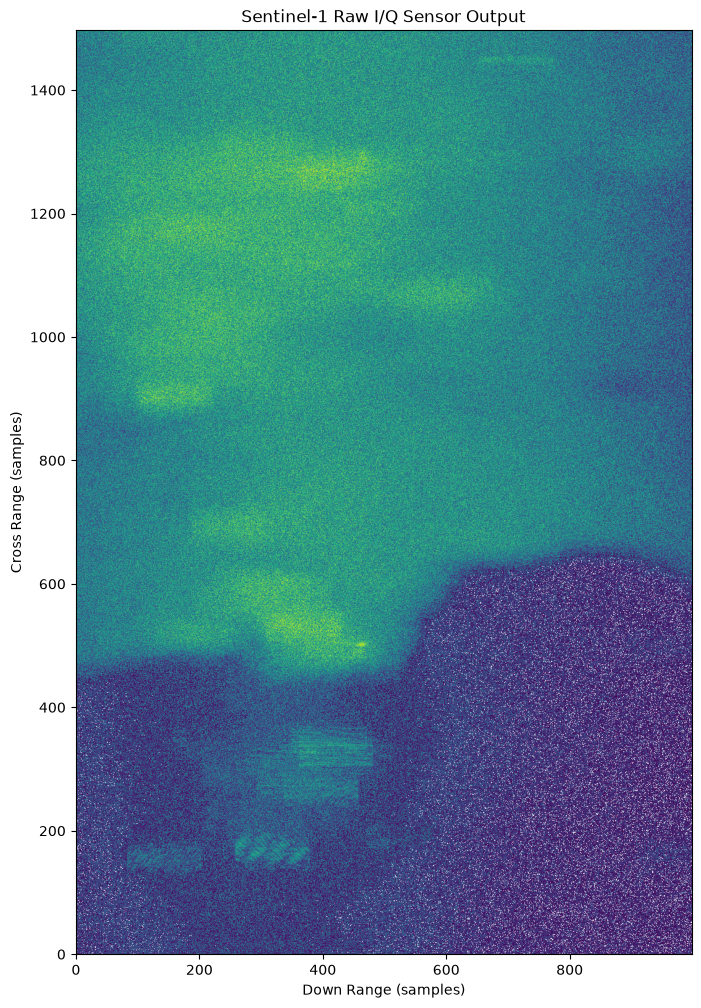

In [7]:
# Quick-look only
plt.figure(figsize=(12, 12))
plt.title("Sentinel-1 Raw I/Q Sensor Output")
plt.imshow(
    np.abs(radar_data[::20, ::20]),
    origin="lower",
    norm=colors.LogNorm()
)
plt.xlabel("Down Range (samples)")
plt.ylabel("Cross Range (samples)")
plt.show()


## 4 - Processing parameters and geometry

In [8]:
# Radar parameters
c = sentinel1decoder.constants.SPEED_OF_LIGHT_MPS #Tốc độ ánh sáng
wavelength_m = sentinel1decoder.constants.TX_WAVELENGTH_M 

RGDEC = selection["Range Decimation"].iloc[0] 
PRI = selection["PRI"].iloc[0]
rank = selection["Rank"].iloc[0]

TXPSF = selection["Tx Pulse Start Frequency"].iloc[0]
TXPRR = selection["Tx Ramp Rate"].iloc[0]
TXPL = selection["Tx Pulse Length"].iloc[0]

range_sample_freq = sentinel1decoder.utilities.range_dec_to_sample_rate(RGDEC)
range_sample_period = 1.0 / range_sample_freq
az_sample_freq = 1.0 / PRI
az_sample_period = PRI

suppressed_data_time = 320.0 / (8.0 * sentinel1decoder.constants.F_REF)

# Range-time axis of the decoded raw line
range_start_time = selection["SWST"].iloc[0] + suppressed_data_time
raw_fast_time_vec_s = range_start_time + np.arange(raw_len_range_line) / range_sample_freq
raw_slant_range_time_vec_s = rank * PRI + raw_fast_time_vec_s
raw_slant_range_vec_m = raw_slant_range_time_vec_s * c / 2.0

# Azimuth time of each echo packet
packet_azimuth_times_s = (
    selection["Coarse Time"].to_numpy(dtype=float)
    + selection["Fine Time"].to_numpy(dtype=float)
)

# --- PHẦN BỔ SUNG IN TẤT CẢ CÁC BIẾN ---
print("=== HẰNG SỐ & THAM SỐ RADAR HỆ THỐNG ===")
print("Speed of light (c):", c, "m/s")
print("Wavelength:", wavelength_m, "m")
print("Range Decimation (RGDEC):", RGDEC)
print("PRI:", PRI, "s")
print("Rank:", rank)
print("Tx Pulse Start Frequency (TXPSF):", TXPSF, "Hz")
print("Tx Ramp Rate (TXPRR):", TXPRR, "Hz/s")
print("Tx Pulse Length (TXPL):", TXPL, "s")

print("\n=== TẦN SỐ VÀ CHU KỲ LẤY MẪU ===")
print("Range sampling frequency:", range_sample_freq / 1e6, "MHz")
print("Range sampling period:", range_sample_period, "s")
print("PRF (Azimuth sampling frequency):", az_sample_freq, "Hz")
print("Azimuth sampling period:", az_sample_period, "s")
print("Suppressed data time:", suppressed_data_time, "s")

print("\n=== THÔNG SỐ TRỤC RANGE (KHOẢNG CÁCH) ===")
print("Raw range samples (Số lượng mẫu):", raw_len_range_line)
print("Range start time:", range_start_time, "s")

# Đối với mảng dữ liệu (vector), in kích thước và giá trị đầu/cuối để tránh tràn màn hình
print("\n=== DỮ LIỆU VECTOR (MẢNG) ===")
print(f"raw_fast_time_vec_s (Kích thước: {raw_fast_time_vec_s.shape}):")
print(f"  - Bắt đầu: {raw_fast_time_vec_s[0]} s")
print(f"  - Kết thúc: {raw_fast_time_vec_s[-1]} s")

print(f"raw_slant_range_time_vec_s (Kích thước: {raw_slant_range_time_vec_s.shape}):")
print(f"  - Bắt đầu: {raw_slant_range_time_vec_s[0]} s")
print(f"  - Kết thúc: {raw_slant_range_time_vec_s[-1]} s")

print(f"raw_slant_range_vec_m (Kích thước: {raw_slant_range_vec_m.shape}):")
print(f"  - Gần nhất (Near range): {raw_slant_range_vec_m[0] / 1000.0} km")
print(f"  - Xa nhất (Far range): {raw_slant_range_vec_m[-1] / 1000.0} km")

print(f"packet_azimuth_times_s (Kích thước: {packet_azimuth_times_s.shape}):")
print(f"  - Bắt đầu: {packet_azimuth_times_s[0]} s")
print(f"  - Kết thúc: {packet_azimuth_times_s[-1]} s")


=== HẰNG SỐ & THAM SỐ RADAR HỆ THỐNG ===
Speed of light (c): 299792458.0 m/s
Wavelength: 0.055465764662349676 m
Range Decimation (RGDEC): RGDEC 9
PRI: 0.000601150045968743 s
Rank: 10
Tx Pulse Start Frequency (TXPSF): -21094036.48895405 Hz
Tx Ramp Rate (TXPRR): 825635554407.1796 Hz/s
Tx Pulse Length (TXPL): 5.109935242723139e-05 s

=== TẦN SỐ VÀ CHU KỲ LẤY MẪU ===
Range sampling frequency: 46.9184028 MHz
Range sampling period: 2.1313598509794114e-08 s
PRF (Azimuth sampling frequency): 1663.4782059918455 Hz
Azimuth sampling period: 0.000601150045968743 s
Suppressed data time: 1.0656799254897057e-06 s

=== THÔNG SỐ TRỤC RANGE (KHOẢNG CÁCH) ===
Raw range samples (Số lượng mẫu): 19950
Range start time: 8.44018500987847e-05 s

=== DỮ LIỆU VECTOR (MẢNG) ===
raw_fast_time_vec_s (Kích thước: (19950,)):
  - Bắt đầu: 8.44018500987847e-05 s
  - Kết thúc: 0.0005095868267706675 s
raw_slant_range_time_vec_s (Kích thước: (19950,)):
  - Bắt đầu: 0.006095902309786214 s
  - Kết thúc: 0.006521087286458098

In [9]:
# Precise effective-velocity estimator.
#
# The helper sorts and de-duplicates the L0 PVT orbit epochs, then constructs
# a cubic Hermite orbit interpolator using both ECEF position and velocity.
vr_estimator = make_estimator_from_notebook(
    l0file,
    wavelength_m
)

print("Unique orbit epochs:", vr_estimator.orbit_times_s.size)
print(
    "Orbit interval:",
    vr_estimator.orbit_times_s[0],
    "to",
    vr_estimator.orbit_times_s[-1],
    "GPS seconds"
)

# Packet Coarse/Fine Time and POD Solution Data Timestamp are in the same
# GPS-time basis in sentinel1decoder. Do not mix these with UTC annotation
# timestamps without applying the GPS-UTC offset.
if (
    packet_azimuth_times_s[0] < vr_estimator.orbit_times_s[0]
    or packet_azimuth_times_s[-1] > vr_estimator.orbit_times_s[-1]
):
    raise ValueError(
        "Echo packet times are outside the available ephemeris interval."
    )

print(
    "Echo interval:",
    packet_azimuth_times_s[0],
    "to",
    packet_azimuth_times_s[-1],
    "GPS seconds"
)


Unique orbit epochs: 31
Orbit interval: 1450820654.0 to 1450820684.0 GPS seconds
Echo interval: 1450820654.910637 to 1450820672.904869 GPS seconds


Orbit interpolation is now encapsulated in `PreciseEffectiveVelocity`.

The old `interp1d` position/velocity interpolation and the approximate
`V_r = sqrt(V_s V_g)` geometry are intentionally removed from this notebook.


## 5 - Doppler Centroid records

In [10]:
DCE_RECORDS = prepare_annotation_records([
    {
        "azimuthTime": "2025-12-26T21:43:59.100490",
        "t0": 6.095910535477454e-03,
        "dataDcPolynomial": [4.152910e+01, 1.012491e+05, -4.252661e+08],
        "fineStart": "2025-12-26T21:43:57.297041",
        "fineStop": "2025-12-26T21:44:00.903940",
    },
    {
        "azimuthTime": "2025-12-26T21:44:14.095877",
        "t0": 6.095910535477454e-03,
        "dataDcPolynomial": [1.141131e+01, 1.275731e+04, 6.579813e+07],
        "fineStart": "2025-12-26T21:44:12.292428",
        "fineStop": "2025-12-26T21:44:15.899327",
    },
    {
        "azimuthTime": "2025-12-26T21:44:25.484967",
        "t0": 6.095910535477454e-03,
        "dataDcPolynomial": [3.263240e+01, -2.579159e+03, -1.314992e+08],
        "fineStart": "2025-12-26T21:44:23.681518",
        "fineStop": "2025-12-26T21:44:27.288417",
    },
])


def dce_for_block(block_center_index):
    return evaluate_annotation_dce(
        DCE_RECORDS,
        packet_azimuth_times_s[block_center_index],
        slant_range_time_vec_s,
    )


print("DCE centres (GPS s):", [rec["azimuth_s"] for rec in DCE_RECORDS])
print(
    "Echo packet interval (GPS s):",
    packet_azimuth_times_s[0],
    packet_azimuth_times_s[-1],
)


DCE centres (GPS s): [1450820657.10049, 1450820672.095877, 1450820683.484967]
Echo packet interval (GPS s): 1450820654.910637 1450820672.904869


## 6 - Range compression

In [11]:
range_compressed, slant_range_time_vec_s = compress_range(
    radar_data,
    raw_slant_range_time_vec_s,
    sample_rate_hz=range_sample_freq,
    pulse_start_frequency_hz=TXPSF,
    pulse_ramp_rate_hz_per_s=TXPRR,
    pulse_length_s=TXPL,
)
slant_range_vec_m = slant_range_time_vec_s * c / 2.0
len_range_line = range_compressed.shape[1]
del radar_data

print("Range-compressed shape:", range_compressed.shape)
print("Valid range samples:", len_range_line)


Range-compressed shape: (29934, 17553)
Valid range samples: 17553


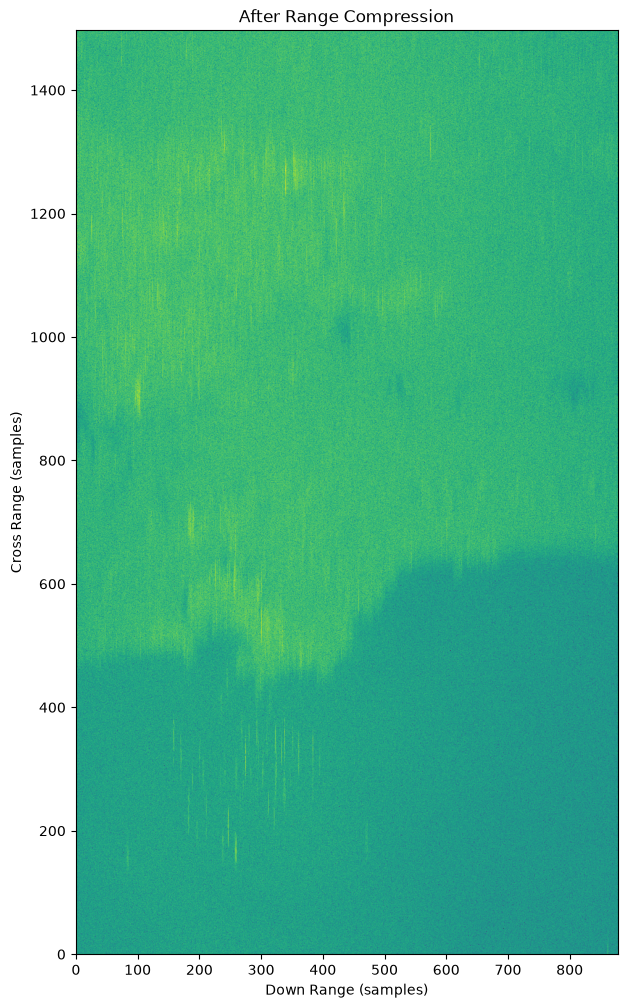

In [12]:
# Quick-look after range compression.
plt.figure(figsize=(12, 12))
plt.title("After Range Compression")
plt.imshow(
    np.abs(range_compressed[::20, ::20]),
    origin="lower",
    norm=colors.LogNorm()
)
plt.xlabel("Down Range (samples)")
plt.ylabel("Cross Range (samples)")
plt.show()


## 7 - Focusing configuration

In [13]:
# Sentinel-1 Stripmap S6 parameters from AUX_PP1.
AZIMUTH_PROCESSING_BANDWIDTH_HZ = 1398.0
FOCUS_FFT_LEN = 4096
EXTRA_AZIMUTH_PROCESSING_BLOCK_OVERLAP = 50
MAX_FDC_HZ = 100.0
SRC_SEGMENT_SAMPLES = 1024
RCMC_KERNEL_LENGTH = 16
RCMC_NUM_PHASES = 64

slc_layout = estimate_slc_layout(
    len_az_line,
    slant_range_vec_m,
    packet_azimuth_times_s,
    dce_for_block,
    vr_estimator,
    wavelength_m=wavelength_m,
    azimuth_sample_frequency_hz=az_sample_freq,
    processing_bandwidth_hz=AZIMUTH_PROCESSING_BANDWIDTH_HZ,
    fft_length=FOCUS_FFT_LEN,
    extra_overlap_samples=EXTRA_AZIMUTH_PROCESSING_BLOCK_OVERLAP,
)
MATCHED_FILTER_SUPPORT_SAMPLES = slc_layout.matched_filter_support_samples
FOCUS_OVERLAP_SAMPLES = slc_layout.overlap_samples
FOCUS_STEP = slc_layout.step_samples

print("Support probes:", slc_layout.support_probe_indices.tolist())
print("A probes:", list(slc_layout.support_probe_samples))
print("Configured/estimated A:", MATCHED_FILTER_SUPPORT_SAMPLES, "samples")
print("Total focus overlap:", FOCUS_OVERLAP_SAMPLES, "samples")
print("Focus step:", FOCUS_STEP, "samples")


Support probes: [0, 7483, 14966, 22450, 29933]
A probes: [1203, 1210, 1212, 1210, 1212]
Configured/estimated A: 1212 samples
Total focus overlap: 1262 samples
Focus step: 2834 samples


## 8 - Secondary Range Compression (SRC)

`sentinel1_processing.src` applies SRC inside each azimuth block.


## 9 - Sinc RCMC

`sentinel1_processing.rcmc` applies fractional-delay sinc RCMC.


## 10 - Azimuth focusing of one block

`sentinel1_processing.azimuth_compression` performs block focusing.


In [14]:
# Diagnostic: V_r is computed here, before focusing.
_vr_test_index = len_az_line // 2
_vr_test = vr_estimator.evaluate_block(
    block_center_time_s=packet_azimuth_times_s[_vr_test_index],
    slant_range_m=slant_range_vec_m,
    fdc_hz=dce_for_block(_vr_test_index),
    azimuth_bandwidth_hz=AZIMUTH_PROCESSING_BANDWIDTH_HZ,
    n_control_points=9,
    range_polynomial_degree=2,
    return_diagnostics=True,
)
print(
    "V_r near/mid/far [m/s]:",
    _vr_test.vr_mps[0],
    _vr_test.vr_mps[len_range_line // 2],
    _vr_test.vr_mps[-1],
)
print(
    "Hyperbolic fit RMS range [m], max over control points:",
    max(point.fit_rms_m for point in _vr_test.control_points),
)
del _vr_test


V_r near/mid/far [m/s]: 7202.557628416208 7201.769180700679 7200.88648848409
Hyperbolic fit RMS range [m], max over control points: 0.0005815043542565907


## 11 - Focus all azimuth blocks and stitch

In [15]:
focused_image = assemble_slc(
    range_compressed,
    slant_range_vec_m,
    packet_azimuth_times_s,
    dce_for_block,
    vr_estimator,
    slc_layout,
    wavelength_m=wavelength_m,
    speed_of_light_mps=c,
    azimuth_sample_period_s=az_sample_period,
    range_sample_period_s=range_sample_period,
    range_sample_frequency_hz=range_sample_freq,
    processing_bandwidth_hz=AZIMUTH_PROCESSING_BANDWIDTH_HZ,
    fft_length=FOCUS_FFT_LEN,
    src_segment_samples=SRC_SEGMENT_SAMPLES,
    rcmc_kernel_length=RCMC_KERNEL_LENGTH,
    rcmc_phases=RCMC_NUM_PHASES,
)
del range_compressed
print("Focused image shape:", focused_image.shape)


Focused image shape: (29934, 17553)


## 12 - Display focused image

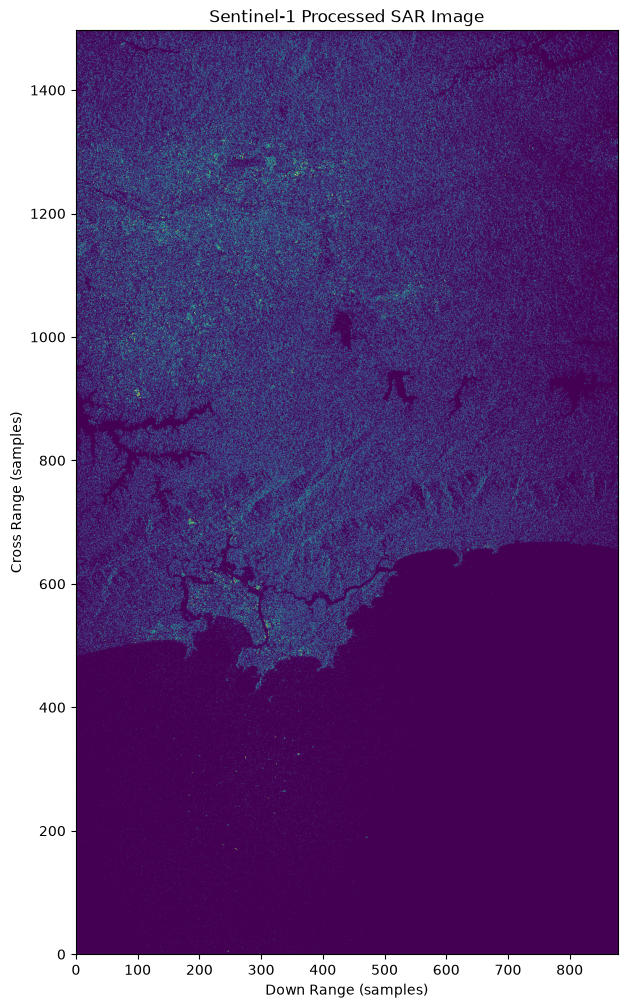

In [17]:
# Display scaling follows the normalized range matched filter.
tx_replica_sample_count = int(np.ceil(TXPL * range_sample_freq))
display_amplitude_scale = np.sqrt(tx_replica_sample_count)
valid_range_start = int(np.rint(
    (slant_range_time_vec_s[0] - raw_slant_range_time_vec_s[0])
    * range_sample_freq
))

plt.figure(figsize=(12, 12))
plt.title("Sentinel-1 Processed SAR Image")
plt.imshow(
    np.abs(focused_image[::20, ::20]),
    origin="lower",
    norm=colors.LogNorm(
        vmin=300 / display_amplitude_scale,
        vmax=10000 / display_amplitude_scale,
    ),
)
plt.xlabel("Down Range (samples)")
plt.ylabel("Cross Range (samples)")
plt.show()


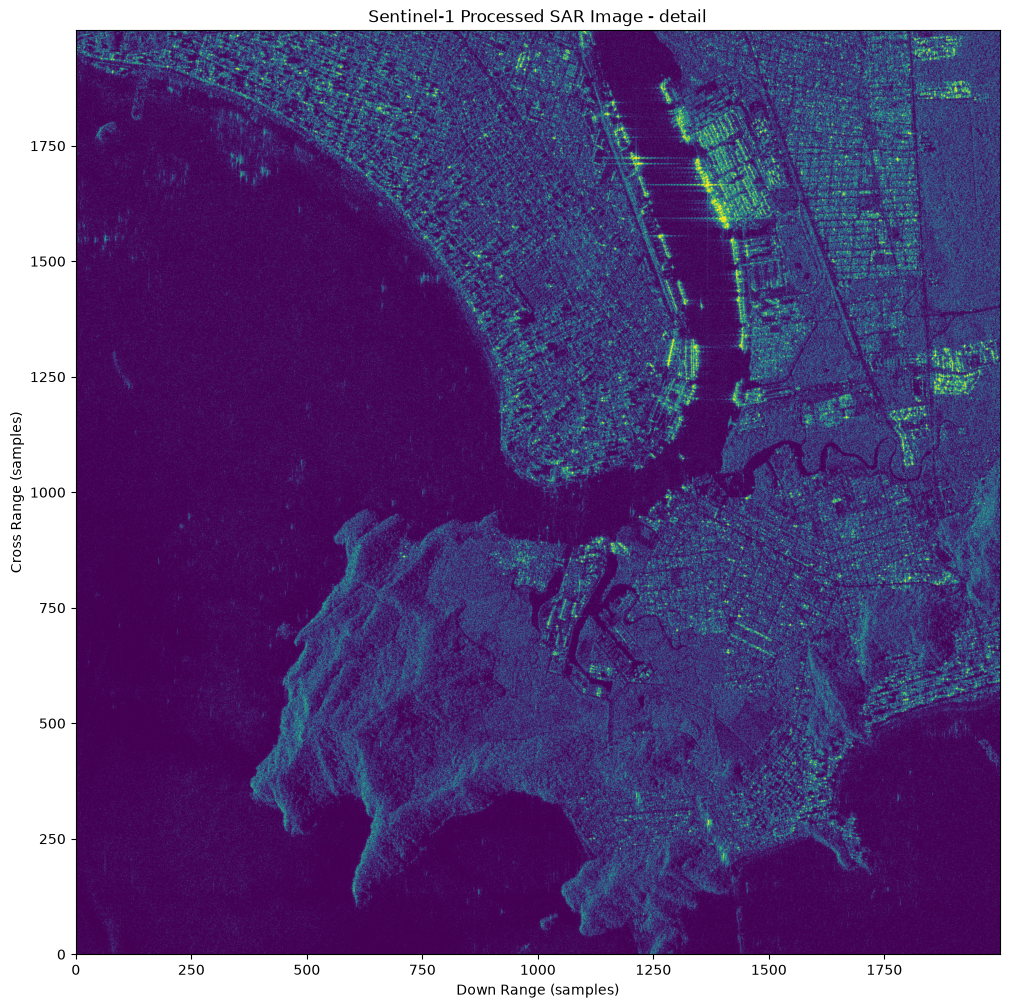

Total runtime: 617.14 s (10.29 min)


In [18]:
# Convert the Demo's raw-range window to the valid compressed-range grid.
plt.figure(figsize=(12, 12))
plt.title("Sentinel-1 Processed SAR Image - detail")
plt.imshow(
    np.abs(focused_image[
        9000:11000,
        6000 - valid_range_start:8000 - valid_range_start,
    ]),
    origin="lower",
    norm=colors.LogNorm(
        vmin=300 / display_amplitude_scale,
        vmax=10000 / display_amplitude_scale,
    ),
)
plt.xlabel("Down Range (samples)")
plt.ylabel("Cross Range (samples)")
plt.show()

elapsed = perf_counter() - notebook_started_at
print(f"Total runtime: {elapsed:.2f} s ({elapsed / 60:.2f} min)")


## 13 - Export amplitude TIFF for SNAP comparison

In [ ]:
# %pip install -q tifffile

# import tifffile

# tiff_path = "simple_focused_amplitude_raw_grid.tif"
# tiff = tifffile.memmap(
#     tiff_path,
#     shape=(len_az_line, raw_len_range_line),
#     dtype=np.float32,
#     bigtiff=True,
#     photometric="minisblack",
# )

# tiff[:, :valid_range_start] = np.nan
# tiff[:, valid_range_start + len_range_line:] = np.nan
# for a0 in range(0, len_az_line, RANGE_CHUNK):
#     a1 = min(a0 + RANGE_CHUNK, len_az_line)
#     tiff[a0:a1, valid_range_start:valid_range_start + len_range_line] = np.abs(focused_image[a0:a1])

# tiff.flush()
# del tiff
# print("Saved for SNAP:", tiff_path)
